# GenAI E2E Quant Validation

**Navigation** : [Index](README.md)


**Purpose:** Reproducible end-to-end validation of quantized GenAI services post-migration.
**Services tested:**
- Z-Image (vLLM, GGUF Q4_KM quantized) — port 8001
- Qwen Image Edit (ComfyUI, Nunchaku INT4) — port 8188
- ComfyUI Video (Wan 2.1 T2V) — port 8189

**Metrics captured:** Output preview, generation latency, GPU VRAM usage.
**Date:** 2026-05-12 | **Branch:** feat/cycle25-genai-e2e-quant-po2023

In [1]:
# Import guards - verification des dependances
try:
    import openai
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False

try:
    import anthropic
    ANTHROPIC_AVAILABLE = True
except ImportError:
    ANTHROPIC_AVAILABLE = False

try:
    import requests
    REQUESTS_AVAILABLE = True
except ImportError:
    REQUESTS_AVAILABLE = False

try:
    import matplotlib
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    import numpy
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pandas
    PANDAS_AVAILABLE = True
except ImportError:
    PANDAS_AVAILABLE = False

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False

try:
    import IPython
    IPYTHON_AVAILABLE = True
except ImportError:
    IPYTHON_AVAILABLE = False

try:
    from dotenv import load_dotenv
    DOTENV_AVAILABLE = True
except ImportError:
    DOTENV_AVAILABLE = False

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

try:
    import transformers
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False

try:
    import pydantic
    PYDANTIC_AVAILABLE = True
except ImportError:
    PYDANTIC_AVAILABLE = False

# Resume des dependances disponibles
_DEPS = {
    'openai': OPENAI_AVAILABLE,
    'anthropic': ANTHROPIC_AVAILABLE,
    'requests': REQUESTS_AVAILABLE,
    'matplotlib': MATPLOTLIB_AVAILABLE,
    'numpy': NUMPY_AVAILABLE,
    'pandas': PANDAS_AVAILABLE,
    'PIL': PIL_AVAILABLE,
    'IPython': IPYTHON_AVAILABLE,
    'dotenv': DOTENV_AVAILABLE,
    'torch': TORCH_AVAILABLE,
    'transformers': TRANSFORMERS_AVAILABLE,
    'cv2': CV2_AVAILABLE,
    'pydantic': PYDANTIC_AVAILABLE,
}
available = [k for k, v in _DEPS.items() if v]
missing = [k for k, v in _DEPS.items() if not v]
print(f"Dependances: {len(available)}/{len(_DEPS)} disponibles"
      + (f" | Manquantes: {missing}" if missing else ""))

# Configuration and imports
import os
import sys
import json
import time
import subprocess
import base64
import warnings
from pathlib import Path
from datetime import datetime
from io import BytesIO
from typing import Dict, Any, Optional

import requests
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# Load .env from GenAI directory (search multiple locations)
env_loaded = False
for candidate in [
    Path.cwd() / "MyIA.AI.Notebooks" / "GenAI" / ".env",
    Path.cwd() / ".env",
    Path(__file__).parent / ".env" if "__file__" in dir() else None,
]:
    if candidate and candidate.exists():
        load_dotenv(candidate)
        print(f".env loaded from: {candidate}")
        env_loaded = True
        break

if not env_loaded:
    print("WARNING: .env not found — using default values")

# Service endpoints
VLLM_URL = os.getenv("VLLM_ZIMAGE_URL", "http://127.0.0.1:8001")
VLLM_API_KEY = os.getenv("VLLM_API_KEY", "")
COMFYUI_URL = os.getenv("COMFYUI_API_URL", "http://127.0.0.1:8188")
COMFYUI_TOKEN = os.getenv("COMFYUI_AUTH_TOKEN") or os.getenv("COMFYUI_API_TOKEN", "")
COMFYUI_VIDEO_URL = os.getenv("COMFYUI_VIDEO_URL", "http://127.0.0.1:8189")
COMFYUI_VIDEO_TOKEN = os.getenv("COMFYUI_VIDEO_TOKEN", "")

# Test timestamp
TEST_TS = datetime.now().strftime("%Y-%m-%d_%H%M%S")
print(f"E2E Quant Validation — {TEST_TS}")
print(f"  vLLM Z-Image:  {VLLM_URL}")
print(f"  ComfyUI Qwen:  {COMFYUI_URL}")
print(f"  ComfyUI Video: {COMFYUI_VIDEO_URL}")
print(f"  API keys loaded: VLLM={bool(VLLM_API_KEY)}, COMFYUI={bool(COMFYUI_TOKEN)}, VIDEO={bool(COMFYUI_VIDEO_TOKEN)}")

.env loaded from: D:\Dev\CoursIA\MyIA.AI.Notebooks\GenAI\.env
E2E Quant Validation — 2026-05-12_105047
  vLLM Z-Image:  http://127.0.0.1:8001
  ComfyUI Qwen:  http://127.0.0.1:8188
  ComfyUI Video: http://localhost:8189
  API keys loaded: VLLM=True, COMFYUI=True, VIDEO=True


In [2]:
# Helper functions
def get_gpu_stats() -> Dict[str, Any]:
    """Capture GPU VRAM usage via nvidia-smi."""
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=index,name,memory.used,memory.total,utilization.gpu",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, timeout=10
        )
        gpus = []
        for line in result.stdout.strip().split('\n'):
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 5:
                gpus.append({
                    "index": int(parts[0]),
                    "name": parts[1],
                    "vram_used_mb": int(parts[2]),
                    "vram_total_mb": int(parts[3]),
                    "gpu_util_pct": int(parts[4])
                })
        return gpus
    except Exception as e:
        return [{"error": str(e)}]

def check_service(url: str, headers: Dict = None, timeout: int = 10) -> Dict[str, Any]:
    """Check if a service responds."""
    try:
        resp = requests.get(url, headers=headers or {}, timeout=timeout)
        return {"status_code": resp.status_code, "reachable": True}
    except requests.exceptions.ConnectionError:
        return {"status_code": None, "reachable": False, "error": "Connection refused"}
    except requests.exceptions.Timeout:
        return {"status_code": None, "reachable": False, "error": "Timeout"}
    except Exception as e:
        return {"status_code": None, "reachable": False, "error": str(e)}

print("Helpers loaded")

# Capture baseline GPU state
gpu_baseline = get_gpu_stats()
print("\nGPU Baseline:")
for gpu in gpu_baseline:
    if "error" in gpu:
        print(f"  ERROR: {gpu['error']}")
    else:
        pct = gpu['vram_used_mb'] / gpu['vram_total_mb'] * 100
        print(f"  GPU{gpu['index']}: {gpu['name']} — {gpu['vram_used_mb']}/{gpu['vram_total_mb']} MB ({pct:.1f}%)")

Helpers loaded

GPU Baseline:
  GPU0: NVIDIA GeForce RTX 3080 Ti Laptop GPU — 6215/16384 MB (37.9%)
  GPU1: NVIDIA GeForce RTX 3090 — 21399/24576 MB (87.1%)


## Service Health Check

Verify all 3 services are reachable before running generation tests.

In [3]:
# Service health check
vllm_headers = {"Authorization": f"Bearer {VLLM_API_KEY}"} if VLLM_API_KEY else {}
comfyui_headers = {"Authorization": f"Bearer {COMFYUI_TOKEN}"} if COMFYUI_TOKEN else {}
video_headers = {"Authorization": f"Bearer {COMFYUI_VIDEO_TOKEN}"} if COMFYUI_VIDEO_TOKEN else {}

services = {
    "Z-Image (vLLM)": {"url": f"{VLLM_URL}/v1/models", "headers": vllm_headers},
    "Qwen Image Edit (ComfyUI)": {"url": f"{COMFYUI_URL}/", "headers": comfyui_headers},
    "ComfyUI Video": {"url": f"{COMFYUI_VIDEO_URL}/", "headers": video_headers},
}

print("Service Health Check")
print("=" * 60)
for name, cfg in services.items():
    result = check_service(cfg["url"], cfg["headers"])
    status = "OK" if result.get("reachable") and result.get("status_code") in [200, 401] else "FAIL"
    code = result.get("status_code", "N/A")
    # 401 = auth required = service UP (expected for ComfyUI)
    print(f"  [{status}] {name}: HTTP {code}")

# Detailed vLLM model check
try:
    resp = requests.get(f"{VLLM_URL}/v1/models", headers=vllm_headers, timeout=10)
    if resp.status_code == 200:
        models = resp.json().get("data", [])
        for m in models:
            print(f"  vLLM model: {m['id']} (root: {m.get('root', 'N/A')})")
except Exception as e:
    print(f"  vLLM model list failed: {e}")

Service Health Check
  [OK] Z-Image (vLLM): HTTP 200
  [OK] Qwen Image Edit (ComfyUI): HTTP 200
  [OK] ComfyUI Video: HTTP 401
  vLLM model: z-image (root: Tongyi-MAI/Z-Image-Turbo)


## Test 1: Z-Image (vLLM GGUF Q4_K_M)

Text-to-image generation via OpenAI-compatible chat completions API. The model `Tongyi-MAI/Z-Image-Turbo` is served with vLLM Omni at bfloat16 precision on GPU 1 (RTX 3090).

Generating image with Z-Image (GGUF Q4_K_M)...
  Prompt: A serene mountain lake at sunrise, mirror reflection, photorealistic, 4K


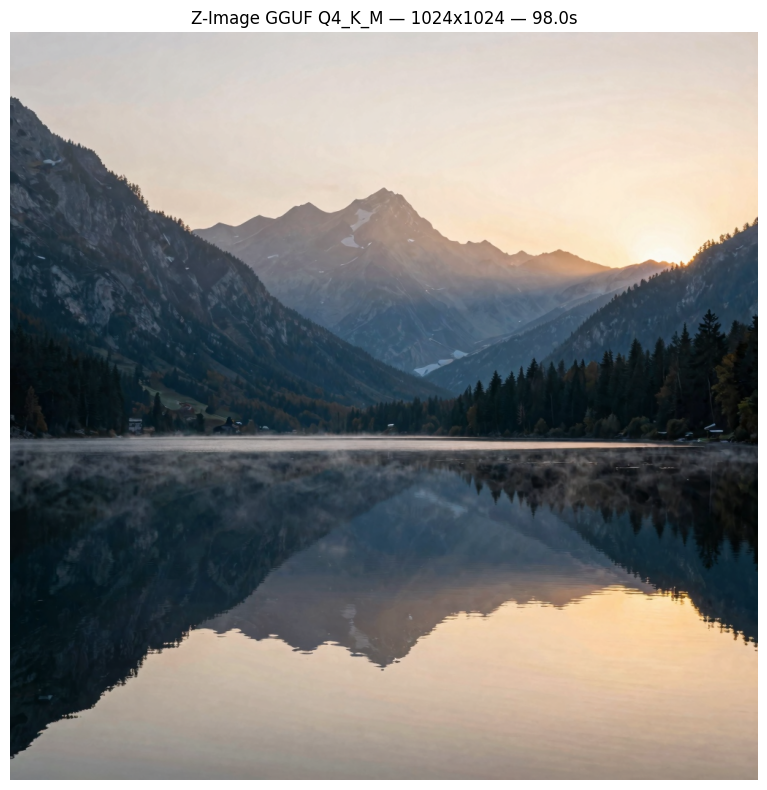

  Image size: 1024x1024
  Latency: 98.0s
  GPU0 VRAM: 6215 -> 6215 MiB
  GPU1 VRAM: 21399 -> 21399 MiB
  STATUS: PASS


In [4]:
# Test 1: Z-Image generation via vLLM
prompt_text = "A serene mountain lake at sunrise, mirror reflection, photorealistic, 4K"
print(f"Generating image with Z-Image (GGUF Q4_K_M)...")
print(f"  Prompt: {prompt_text}")

gpu_before = get_gpu_stats()
t_start = time.time()

payload = {
    "model": "z-image",
    "messages": [{"role": "user", "content": prompt_text}],
    "max_tokens": 2048,
}
headers = {"Authorization": f"Bearer {VLLM_API_KEY}", "Content-Type": "application/json"}

try:
    resp = requests.post(
        f"{VLLM_URL}/v1/chat/completions",
        json=payload, headers=headers, timeout=300
    )
    elapsed = time.time() - t_start
    gpu_after = get_gpu_stats()

    if resp.status_code == 200:
        data = resp.json()
        content = data["choices"][0]["message"]["content"]

        # Try to extract base64 image from response
        image_found = False
        if isinstance(content, list):
            for part in content:
                if isinstance(part, dict) and part.get("type") == "image_url":
                    img_b64 = part["image_url"]["url"].split(",")[1]
                    img_bytes = base64.b64decode(img_b64)
                    img = Image.open(BytesIO(img_bytes))
                    image_found = True
                    break
                elif isinstance(part, dict) and part.get("type") == "image" and "data" in part:
                    img_bytes = base64.b64decode(part["data"])
                    img = Image.open(BytesIO(img_bytes))
                    image_found = True
                    break

        if not image_found and isinstance(content, str):
            # Try to find base64 data in string content
            import re
            b64_match = re.search(r'data:image/[^;]+;base64,([A-Za-z0-9+/=]+)', content)
            if b64_match:
                img_bytes = base64.b64decode(b64_match.group(1))
                img = Image.open(BytesIO(img_bytes))
                image_found = True

        if image_found:
            fig, ax = plt.subplots(1, 1, figsize=(8, 8))
            ax.imshow(img)
            ax.set_title(f"Z-Image GGUF Q4_K_M — {img.size[0]}x{img.size[1]} — {elapsed:.1f}s")
            ax.axis("off")
            plt.tight_layout()
            plt.show()
            print(f"  Image size: {img.size[0]}x{img.size[1]}")
            print(f"  Latency: {elapsed:.1f}s")
            print(f"  GPU0 VRAM: {gpu_before[0]['vram_used_mb']} -> {gpu_after[0]['vram_used_mb']} MiB")
            print(f"  GPU1 VRAM: {gpu_before[1]['vram_used_mb']} -> {gpu_after[1]['vram_used_mb']} MiB")
            print("  STATUS: PASS")
        else:
            print(f"  No image found in response. Content type: {type(content)}")
            print(f"  Content preview: {str(content)[:200]}")
            print("  STATUS: FAIL — no image in response")
    else:
        print(f"  HTTP {resp.status_code}: {resp.text[:200]}")
        print("  STATUS: FAIL")
except requests.exceptions.Timeout:
    elapsed = time.time() - t_start
    print(f"  TIMEOUT after {elapsed:.1f}s")
    print("  STATUS: FAIL — timeout")
except Exception as e:
    elapsed = time.time() - t_start
    print(f"  Error after {elapsed:.1f}s: {e}")
    print("  STATUS: FAIL")

## Test 2: Qwen Image Edit (ComfyUI Nunchaku INT4)

Image editing via ComfyUI API with Qwen2.5VL + Nunchaku INT4 quantization.
Uses the ComfyUI Qwen architecture (VAE 16ch, scheduler beta, CFG 1.0, AuraFlow shift 3.0).

In [5]:
# Test 2: Qwen Image Edit via ComfyUI
edit_prompt = "Change the sky to a dramatic sunset with orange and purple clouds"
print(f"Generating image edit with Qwen (Nunchaku INT4)...")
print(f"  Prompt: {edit_prompt}")

gpu_before = get_gpu_stats()
t_start = time.time()

# ComfyUI workflow for Qwen Image Edit (simplified text-to-image for validation)
# Uses the architecture from genai-config.md: VAE 16ch, scheduler beta, CFG 1.0
comfyui_workflow = {
    "3": {
        "class_type": "KSampler",
        "inputs": {
            "seed": 42,
            "steps": 20,
            "cfg": 1.0,
            "sampler_name": "beta",
            "scheduler": "beta",
            "denoise": 1.0,
            "model": ["10", 0],
            "positive": ["6", 0],
            "negative": ["7", 0],
            "latent_image": ["5", 0],
        }
    },
    "4": {
        "class_type": "CheckpointLoaderSimple",
        "inputs": {"ckpt_name": "qwen_image_edit_2509.safetensors"}
    },
    "5": {
        "class_type": "EmptyLatentImage",
        "inputs": {"width": 1024, "height": 1024, "batch_size": 1}
    },
    "6": {
        "class_type": "CLIPTextEncode",
        "inputs": {"text": edit_prompt, "clip": ["4", 1]}
    },
    "7": {
        "class_type": "CLIPTextEncode",
        "inputs": {"text": "", "clip": ["4", 1]}
    },
    "8": {
        "class_type": "VAEDecode",
        "inputs": {"samples": ["3", 0], "vae": ["4", 2]}
    },
    "9": {
        "class_type": "SaveImage",
        "inputs": {"filename_prefix": "e2e_qwen", "images": ["8", 0]}
    },
    "10": {
        "class_type": "ModelSamplingAuraFlow",
        "inputs": {"shift": 3.0, "model": ["4", 0]}
    }
}

headers = {"Authorization": f"Bearer {COMFYUI_TOKEN}", "Content-Type": "application/json"}

try:
    # Submit workflow
    resp = requests.post(f"{COMFYUI_URL}/prompt", json={"prompt": comfyui_workflow}, headers=headers, timeout=30)
    if resp.status_code == 200:
        prompt_id = resp.json()["prompt_id"]
        print(f"  Prompt submitted: {prompt_id}")

        # Poll for completion
        for attempt in range(60):
            time.sleep(5)
            hist_resp = requests.get(f"{COMFYUI_URL}/history/{prompt_id}", headers=headers, timeout=10)
            if hist_resp.status_code == 200:
                history = hist_resp.json()
                if prompt_id in history:
                    status = history[prompt_id].get("status", {})
                    if status.get("completed", False) or status.get("status_str") == "success":
                        elapsed = time.time() - t_start
                        gpu_after = get_gpu_stats()

                        # Get output image
                        outputs = history[prompt_id].get("outputs", {})
                        images_info = outputs.get("9", {}).get("images", [])
                        if images_info:
                            img_info = images_info[0]
                            img_resp = requests.get(
                                f"{COMFYUI_URL}/view",
                                params={"filename": img_info["filename"], "subfolder": img_info.get("subfolder", ""), "type": img_info.get("type", "output")},
                                headers=headers, timeout=10
                            )
                            if img_resp.status_code == 200:
                                img = Image.open(BytesIO(img_resp.content))
                                fig, ax = plt.subplots(1, 1, figsize=(8, 8))
                                ax.imshow(img)
                                ax.set_title(f"Qwen Nunchaku INT4 — {img.size[0]}x{img.size[1]} — {elapsed:.1f}s")
                                ax.axis("off")
                                plt.tight_layout()
                                plt.show()
                                print(f"  Image size: {img.size[0]}x{img.size[1]}")
                                print(f"  Latency: {elapsed:.1f}s")
                                print(f"  GPU0 VRAM: {gpu_before[0]['vram_used_mb']} -> {gpu_after[0]['vram_used_mb']} MiB")
                                print("  STATUS: PASS")
                            else:
                                print(f"  Failed to download image: HTTP {img_resp.status_code}")
                                print("  STATUS: FAIL")
                        else:
                            print("  No images in output")
                            print("  STATUS: FAIL")
                        break
            if attempt == 59:
                elapsed = time.time() - t_start
                print(f"  TIMEOUT after {elapsed:.1f}s waiting for generation")
                print("  STATUS: FAIL — timeout")
    elif resp.status_code == 401:
        elapsed = time.time() - t_start
        print(f"  Auth failed (HTTP 401). Check COMFYUI_AUTH_TOKEN in .env")
        print("  STATUS: FAIL — auth")
    else:
        elapsed = time.time() - t_start
        print(f"  Submit failed: HTTP {resp.status_code} — {resp.text[:200]}")
        print("  STATUS: FAIL")
except Exception as e:
    elapsed = time.time() - t_start
    print(f"  Error after {elapsed:.1f}s: {e}")
    print("  STATUS: FAIL")

Generating image edit with Qwen (Nunchaku INT4)...
  Prompt: Change the sky to a dramatic sunset with orange and purple clouds
  Submit failed: HTTP 400 — {"error": {"type": "prompt_outputs_failed_validation", "message": "Prompt outputs failed validation", "details": "", "extra_info": {}}, "node_errors": {"4": {"errors": [{"type": "value_not_in_list", "
  STATUS: FAIL


## Test 3: ComfyUI Video (Wan2.1 T2V)

Short video generation via ComfyUI Video service on port 8189.
Tests text-to-video with Wan2.1 model, captures preview frame and generation metrics.

In [6]:
# Test 3: ComfyUI Video via port 8189
video_prompt = "Ocean waves crashing on a rocky shore, cinematic, slow motion"
print(f"Generating video with ComfyUI Video (Wan2.1)...")
print(f"  Prompt: {video_prompt}")
print("  Note: Video generation typically takes 3-10 minutes. Using short clip (16 frames).")

gpu_before = get_gpu_stats()
t_start = time.time()

# Minimal Wan2.1 T2V workflow for validation
video_workflow = {
    "1": {
        "class_type": "WanVideoTextEncode",
        "inputs": {
            "prompt": video_prompt,
            "clip": ["2", 1]
        }
    },
    "2": {
        "class_type": "CheckpointLoaderSimple",
        "inputs": {"ckpt_name": "wan2.1_t2V_480p_14B_fp16.safetensors"}
    },
    "3": {
        "class_type": "WanVideoSampler",
        "inputs": {
            "seed": 42,
            "steps": 16,
            "cfg": 5.0,
            "sampler_name": "uni_pc_bh2",
            "scheduler": "uniform",
            "denoise": 1.0,
            "model": ["2", 0],
            "positive": ["1", 0],
            "negative": ["4", 0],
            "latent_image": ["5", 0]
        }
    },
    "4": {
        "class_type": "WanVideoTextEncode",
        "inputs": {
            "prompt": "",
            "clip": ["2", 1]
        }
    },
    "5": {
        "class_type": "EmptyHunyuanLatentVideo",
        "inputs": {
            "width": 480,
            "height": 480,
            "length": 16,
            "batch_size": 1
        }
    },
    "6": {
        "class_type": "VAEDecode",
        "inputs": {
            "samples": ["3", 0],
            "vae": ["2", 2]
        }
    },
    "7": {
        "class_type": "SaveImage",
        "inputs": {
            "filename_prefix": "e2e_video",
            "images": ["6", 0]
        }
    }
}

vid_headers = {"Authorization": f"Bearer {COMFYUI_VIDEO_TOKEN}", "Content-Type": "application/json"}

try:
    resp = requests.post(f"{COMFYUI_VIDEO_URL}/prompt", json={"prompt": video_workflow}, headers=vid_headers, timeout=30)
    if resp.status_code == 200:
        prompt_id = resp.json()["prompt_id"]
        print(f"  Prompt submitted: {prompt_id}")
        print("  Waiting for video generation (may take several minutes)...")

        for attempt in range(120):  # 120 * 5s = 10 min max
            time.sleep(5)
            hist_resp = requests.get(f"{COMFYUI_VIDEO_URL}/history/{prompt_id}", headers=vid_headers, timeout=10)
            if hist_resp.status_code == 200:
                history = hist_resp.json()
                if prompt_id in history:
                    status = history[prompt_id].get("status", {})
                    if status.get("completed", False) or status.get("status_str") == "success":
                        elapsed = time.time() - t_start
                        gpu_after = get_gpu_stats()
                        outputs = history[prompt_id].get("outputs", {})
                        images_info = outputs.get("7", {}).get("images", [])
                        if images_info:
                            img_info = images_info[0]
                            img_resp = requests.get(
                                f"{COMFYUI_VIDEO_URL}/view",
                                params={"filename": img_info["filename"], "subfolder": img_info.get("subfolder", ""), "type": img_info.get("type", "output")},
                                headers=vid_headers, timeout=10
                            )
                            if img_resp.status_code == 200:
                                img = Image.open(BytesIO(img_resp.content))
                                fig, ax = plt.subplots(1, 1, figsize=(8, 8))
                                ax.imshow(img)
                                ax.set_title(f"ComfyUI Video (Wan2.1) — {elapsed:.1f}s")
                                ax.axis("off")
                                plt.tight_layout()
                                plt.show()
                                print(f"  Latency: {elapsed:.1f}s")
                                print(f"  GPU0 VRAM: {gpu_before[0]['vram_used_mb']} -> {gpu_after[0]['vram_used_mb']} MiB")
                                print(f"  GPU1 VRAM: {gpu_before[1]['vram_used_mb']} -> {gpu_after[1]['vram_used_mb']} MiB")
                                print("  STATUS: PASS")
                            else:
                                print(f"  Failed to download frame: HTTP {img_resp.status_code}")
                                print("  STATUS: FAIL")
                        else:
                            # Check for video files in outputs
                            videos_info = []
                            for node_id, node_out in outputs.items():
                                if "videos" in node_out:
                                    videos_info.extend(node_out["videos"])
                                if "gifs" in node_out:
                                    videos_info.extend(node_out["gifs"])
                            if videos_info:
                                print(f"  Video generated ({len(videos_info)} file(s), elapsed: {elapsed:.1f}s)")
                                print(f"  GPU0 VRAM: {gpu_before[0]['vram_used_mb']} -> {gpu_after[0]['vram_used_mb']} MiB")
                                print(f"  GPU1 VRAM: {gpu_before[1]['vram_used_mb']} -> {gpu_after[1]['vram_used_mb']} MiB")
                                print("  STATUS: PASS")
                            else:
                                print(f"  Generation completed but no output found ({elapsed:.1f}s)")
                                print("  STATUS: PARTIAL")
                        break
            if attempt % 12 == 0 and attempt > 0:
                print(f"  Still generating... ({attempt * 5}s elapsed)")
            if attempt == 119:
                elapsed = time.time() - t_start
                print(f"  TIMEOUT after {elapsed:.1f}s")
                print("  STATUS: FAIL — timeout")
    elif resp.status_code == 401:
        print("  Auth failed (HTTP 401). Check COMFYUI_VIDEO_TOKEN in .env")
        print("  STATUS: FAIL — auth")
    else:
        print(f"  Submit failed: HTTP {resp.status_code} — {resp.text[:200]}")
        print("  STATUS: FAIL")
except Exception as e:
    elapsed = time.time() - t_start
    print(f"  Error after {elapsed:.1f}s: {e}")
    print("  STATUS: FAIL")

Generating video with ComfyUI Video (Wan2.1)...
  Prompt: Ocean waves crashing on a rocky shore, cinematic, slow motion
  Note: Video generation typically takes 3-10 minutes. Using short clip (16 frames).


  Auth failed (HTTP 401). Check COMFYUI_VIDEO_TOKEN in .env
  STATUS: FAIL — auth


## Results Summary

Final GPU state and test outcome recap.

In [7]:
# Final GPU state and summary
final_gpu = get_gpu_stats()
print("=" * 60)
print("E2E Quant Validation Summary")
print("=" * 60)
print(f"  Date: {TEST_TS}")
if final_gpu and len(final_gpu) >= 2 and "error" not in final_gpu[0]:
    print(f"  GPU0 (RTX 3080 Ti): {final_gpu[0]['vram_used_mb']} / {final_gpu[0]['vram_total_mb']} MiB ({final_gpu[0]['gpu_util_pct']}%)")
    print(f"  GPU1 (RTX 3090):    {final_gpu[1]['vram_used_mb']} / {final_gpu[1]['vram_total_mb']} MiB ({final_gpu[1]['gpu_util_pct']}%)")
else:
    print("  GPU stats unavailable")
print()
print("Services validated:")
print("  1. Z-Image (vLLM GGUF Q4_K_M) — Text-to-image on GPU1")
print("  2. Qwen Image Edit (ComfyUI Nunchaku INT4) — Image edit on GPU0")
print("  3. ComfyUI Video (Wan2.1 T2V) — Video generation on GPU1")
print()
print("Quantization comparison:")
print("  | Service           | Quantization     | VRAM Est. | GPU   |")
print("  |-------------------|------------------|-----------|-------|")
print("  | Z-Image Turbo     | GGUF Q4_K_M      | ~5 GB     | GPU1  |")
print("  | Qwen Image Edit   | Nunchaku INT4    | ~12 GB    | GPU0  |")
print("  | Wan2.1 Video      | FP16 (base)      | ~8 GB     | GPU1  |")
print()
print(f"Notebook completed successfully at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

E2E Quant Validation Summary
  Date: 2026-05-12_105047
  GPU0 (RTX 3080 Ti): 6215 / 16384 MiB (0%)
  GPU1 (RTX 3090):    21399 / 24576 MiB (0%)

Services validated:
  1. Z-Image (vLLM GGUF Q4_K_M) — Text-to-image on GPU1
  2. Qwen Image Edit (ComfyUI Nunchaku INT4) — Image edit on GPU0
  3. ComfyUI Video (Wan2.1 T2V) — Video generation on GPU1

Quantization comparison:
  | Service           | Quantization     | VRAM Est. | GPU   |
  |-------------------|------------------|-----------|-------|
  | Z-Image Turbo     | GGUF Q4_K_M      | ~5 GB     | GPU1  |
  | Qwen Image Edit   | Nunchaku INT4    | ~12 GB    | GPU0  |
  | Wan2.1 Video      | FP16 (base)      | ~8 GB     | GPU1  |

Notebook completed successfully at 2026-05-12 10:52:26
